# AAV5 — Analyse exploratoire (log enrichments, comptages)

Refonte du notebook `analysis` (l'ancienne version est archivée dans `obsolete/`). Charge le CSV
brut `AAV5_organoides.csv` et enchaîne, dans l'ordre :

1. Histogrammes des log2 enrichments — `viab` + organoïde ADN uniquement (4 colonnes ; `noyaux`
   et `arn` retirés).
   1b. Mêmes histogrammes, filtrées sur `compte_virus >= 10`, n indiqué par panneau.
2. Scatter organoïde vs organoïde (log2 enrichment ADN/virus, les 6 paires ordonnées parmi les
   3 réplicats).
3. Scatter viabilité en fonction de chaque réplicat organoïde (3 panneaux).
4. Un dataframe des 100 premiers variants par colonne de comptage (plasmide/virus/organoïde).
5. Un dataframe des % de variants sous divers seuils de comptage, par colonne.
6. Recherche du pseudocount (eps) qui reconstruit le mieux `log2_enrichissement_virus_sur_plasmide`
   à partir des comptages bruts.

### 0. Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CSV_PATH = Path("AAV5_organoides.csv")
if not CSV_PATH.exists():
    here = Path.cwd()
    root = next(p for p in [here, *here.parents] if p.name == "Modelization_V2")
    CSV_PATH = root / "notebooks/notebooks/Selectivity/AAV5/AAV5_organoides.csv"
assert CSV_PATH.exists(), CSV_PATH

count_cols = [
    "compte_plasmide", "compte_virus",
    "compte_organoide_1_adn", "compte_organoide_1_arn",
    "compte_organoide_2_adn", "compte_organoide_2_arn",
    "compte_organoide_3_adn", "compte_organoide_3_arn",
    "compte_noyaux_1_adn", "compte_noyaux_1_arn",
    "compte_noyaux_2_adn", "compte_noyaux_2_arn",
    "compte_noyaux_moyenne_adn", "compte_noyaux_moyenne_arn",
    "compte_controle_negatif",
]
log2_cols = [c for c in pd.read_csv(CSV_PATH, nrows=0).columns if c.startswith("log2_")]
dtypes = {"sequence": "string",
          **{c: "float32" for c in count_cols},
          **{c: "float32" for c in log2_cols}}

df = pd.read_csv(CSV_PATH, dtype=dtypes)
df["sequence"] = df["sequence"].astype("string")
print(f"{df.shape[0]:,} variants x {df.shape[1]} colonnes  |  {len(log2_cols)} colonnes log2_enrichissement_*")
df.head()

5,595,543 variants x 35 colonnes  |  19 colonnes log2_enrichissement_*


,sequence,compte_plasmide,compte_virus,log2_enrichissement_virus_sur_plasmide,compte_organoide_1_adn,compte_organoide_1_arn,log2_enrichissement_organoide_1_adn_sur_virus,log2_enrichissement_organoide_1_arn_sur_virus,log2_enrichissement_organoide_1_arn_sur_adn,compte_organoide_2_adn,...,compte_noyaux_2_arn,log2_enrichissement_noyaux_2_adn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_virus,log2_enrichissement_noyaux_2_arn_sur_adn,compte_noyaux_moyenne_adn,compte_noyaux_moyenne_arn,log2_enrichissement_noyaux_moyenne_adn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_virus,log2_enrichissement_noyaux_moyenne_arn_sur_adn,compte_controle_negatif
0,TEVDRMT,36.5,0.5,-4.928953,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
1,VPQEVVR,8.5,50.5,3.831620,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
2,TGRSDAQ,10.0,8.5,1.026406,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
3,PIRINSN,14.5,1.0,-2.597110,0.0,0.0,NaN,NaN,NaN,0.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0
4,GDTIAMV,8.5,6.0,0.758371,0.0,0.0,NaN,NaN,NaN,6.0,...,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0


### 1. Histogrammes des log enrichments — viab + organoïde ADN uniquement

Colonnes `noyaux` et `arn` retirées (on garde `log2_enrichissement_virus_sur_plasmide` +
`log2_enrichissement_organoide_{1,2,3}_adn_sur_virus`, les 4 cibles utilisées partout ailleurs
dans le projet). Valeurs finies uniquement (bins, jamais KDE). Fraction finie et n indiqués en
titre.

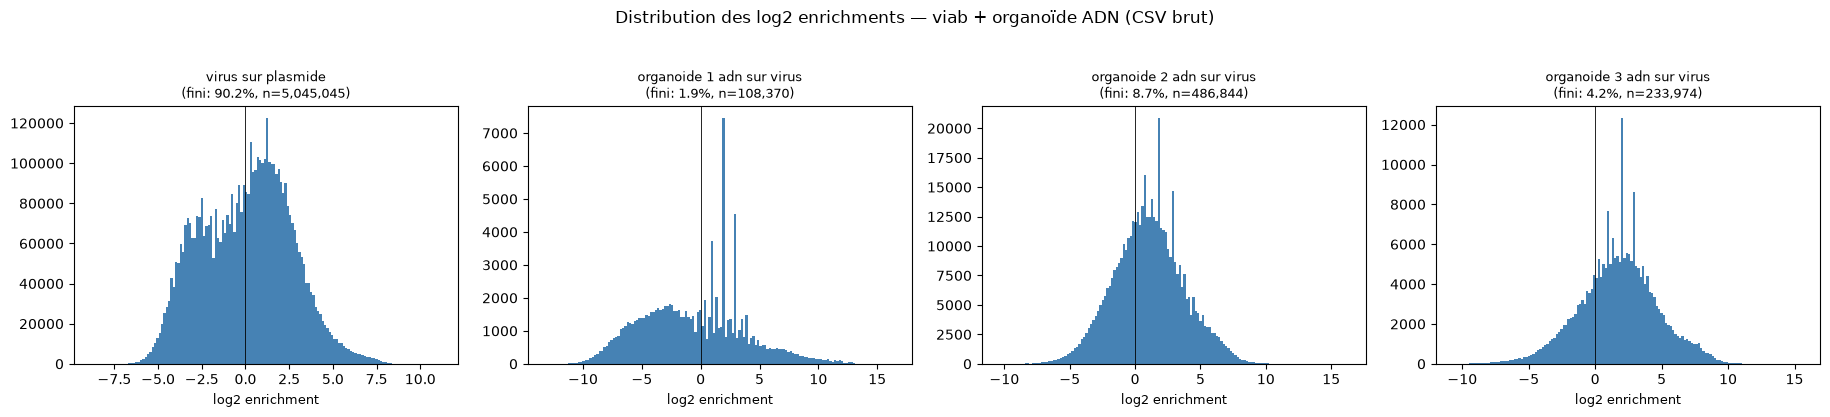

In [15]:
viab_col = "log2_enrichissement_virus_sur_plasmide"
sel_cols = {i: f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)}
log2_cols_main = [viab_col, sel_cols[1], sel_cols[2], sel_cols[3]]

fig, axes = plt.subplots(1, 4, figsize=(4.6 * 4, 4))
for ax, col in zip(axes, log2_cols_main):
    x = df[col].to_numpy(np.float64)
    x = x[np.isfinite(x)]
    short = col.replace("log2_enrichissement_", "").replace("_", " ")
    ax.hist(x, bins=150, color="steelblue")
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{short}\n(fini: {np.isfinite(df[col].to_numpy()).mean():.1%}, n={x.size:,})", fontsize=9)
    ax.set_xlabel("log2 enrichment", fontsize=9)

fig.suptitle("Distribution des log2 enrichments — viab + organoïde ADN (CSV brut)", y=1.03)
plt.tight_layout()
plt.show()

### 1b. Mêmes histogrammes, filtrées sur `compte_virus >= 10`

Retire les variants dont le comptage virus est trop faible (`< 10`, bruit de Poisson dominant)
avant de tracer. Même 4 colonnes que la §1, n (nombre de variants pris en compte) indiqué sur
chaque panneau.

compte_virus >= 10 : 2,430,484 / 5,595,543 variants (43.4%)


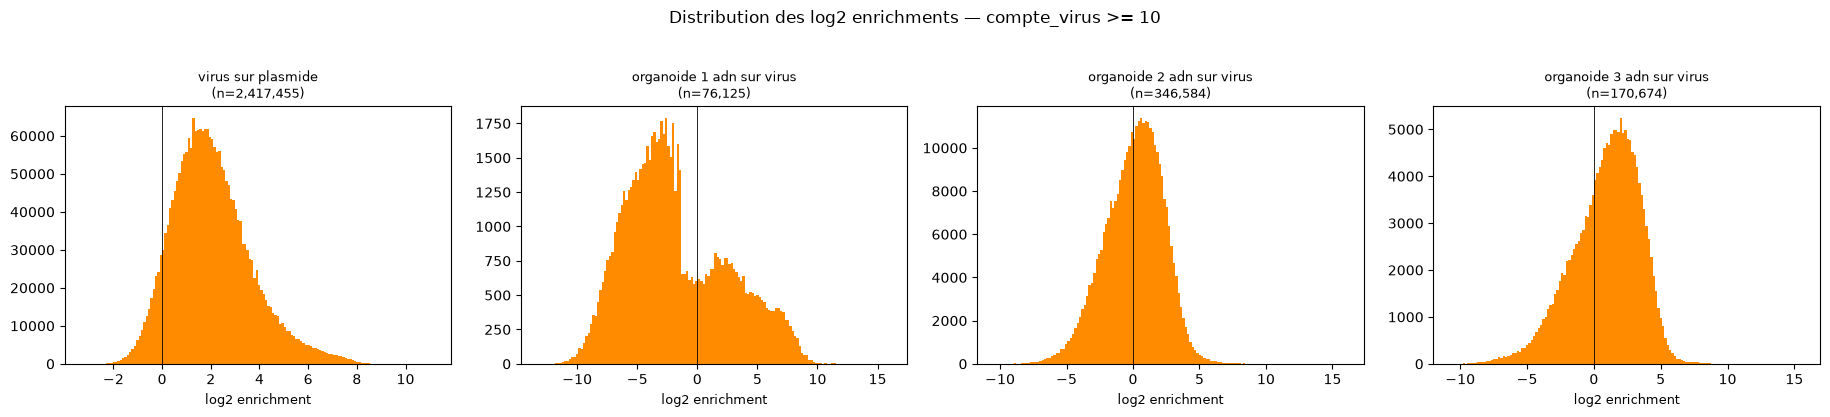

In [16]:
VIRUS_MIN = 10
mask_virus_ok = df["compte_virus"].to_numpy(np.float64) >= VIRUS_MIN
print(f"compte_virus >= {VIRUS_MIN} : {int(mask_virus_ok.sum()):,} / {len(df):,} variants "
      f"({mask_virus_ok.mean():.1%})")

fig, axes = plt.subplots(1, 4, figsize=(4.6 * 4, 4))
for ax, col in zip(axes, log2_cols_main):
    x = df[col].to_numpy(np.float64)
    x = x[mask_virus_ok & np.isfinite(x)]
    short = col.replace("log2_enrichissement_", "").replace("_", " ")
    ax.hist(x, bins=150, color="darkorange")
    ax.axvline(0, color="k", lw=0.6)
    ax.set_title(f"{short}\n(n={x.size:,})", fontsize=9)
    ax.set_xlabel("log2 enrichment", fontsize=9)

fig.suptitle(f"Distribution des log2 enrichments — compte_virus >= {VIRUS_MIN}", y=1.03)
plt.tight_layout()
plt.show()

### 2. Scatter organoïde vs organoïde (log2 enrichment ADN/virus)

Les 6 paires ordonnées parmi les 3 réplicats (org_i = f(org_j) pour chaque (i,j), i≠j) — hexbin
(échelle log de comptage), Pearson r en titre, diagonale y=x en pointillés.

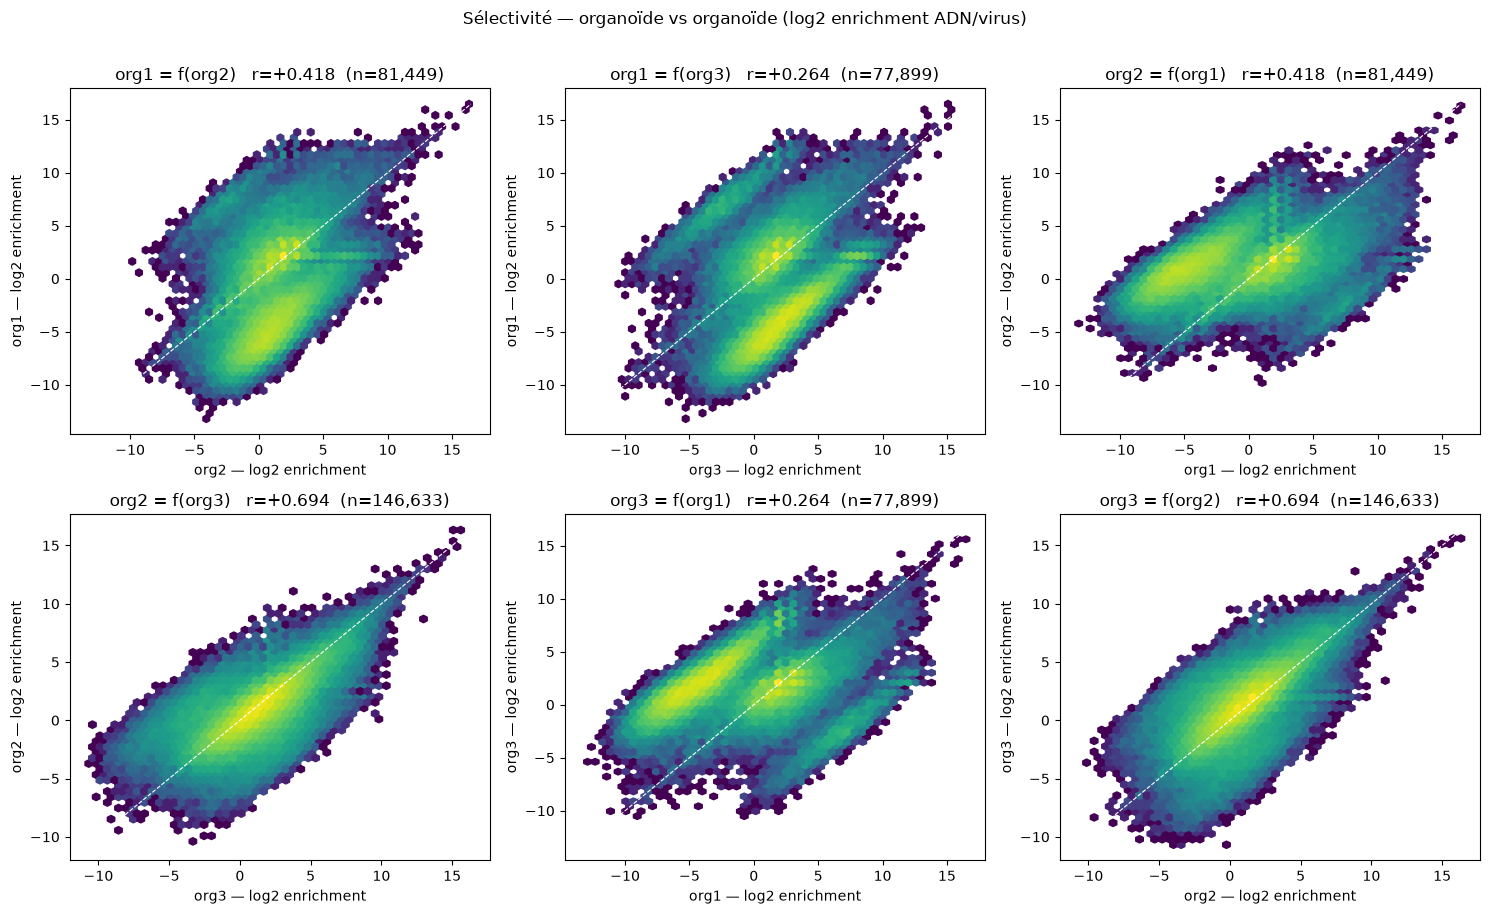

In [17]:
sel_cols = {i: f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)}
pairs_ordered = [(i, j) for i in (1, 2, 3) for j in (1, 2, 3) if i != j]  # 6 paires

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (i, j) in zip(axes.ravel(), pairs_ordered):
    xi, xj = df[sel_cols[i]].to_numpy(np.float64), df[sel_cols[j]].to_numpy(np.float64)
    m = np.isfinite(xi) & np.isfinite(xj)
    r = np.corrcoef(xi[m], xj[m])[0, 1]
    ax.hexbin(xj[m], xi[m], gridsize=50, bins="log", mincnt=1, cmap="viridis")
    lo, hi = min(xi[m].min(), xj[m].min()), max(xi[m].max(), xj[m].max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"org{i} = f(org{j})   r={r:+.3f}  (n={m.sum():,})",
           xlabel=f"org{j} — log2 enrichment", ylabel=f"org{i} — log2 enrichment")

fig.suptitle("Sélectivité — organoïde vs organoïde (log2 enrichment ADN/virus)", y=1.01)
plt.tight_layout()
plt.show()

### 3. Viabilité en fonction de chaque réplicat organoïde

`log2_enrichissement_virus_sur_plasmide` (y) vs chaque `log2_enrichissement_organoide_i_adn_sur_virus`
(x) — 3 panneaux, hexbin, Pearson r en titre.

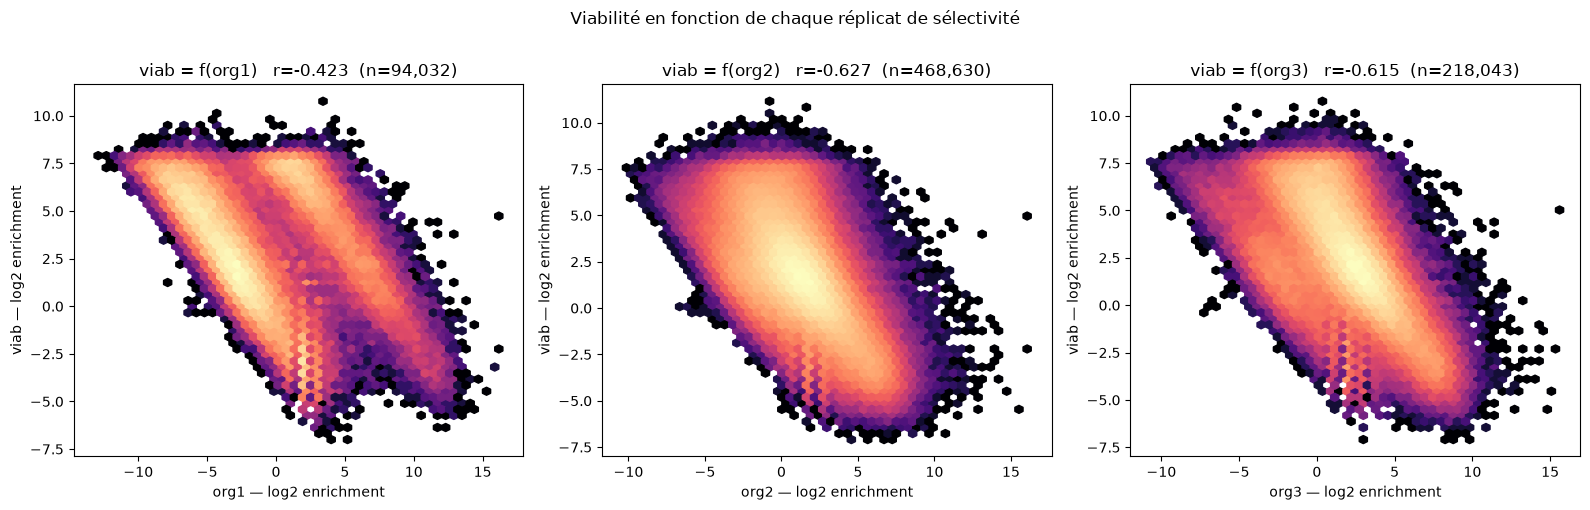

In [18]:
viab_col = "log2_enrichissement_virus_sur_plasmide"
yv = df[viab_col].to_numpy(np.float64)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, i in zip(axes, (1, 2, 3)):
    xi = df[sel_cols[i]].to_numpy(np.float64)
    m = np.isfinite(xi) & np.isfinite(yv)
    r = np.corrcoef(xi[m], yv[m])[0, 1]
    ax.hexbin(xi[m], yv[m], gridsize=50, bins="log", mincnt=1, cmap="magma")
    ax.set(title=f"viab = f(org{i})   r={r:+.3f}  (n={m.sum():,})",
           xlabel=f"org{i} — log2 enrichment", ylabel="viab — log2 enrichment")

fig.suptitle("Viabilité en fonction de chaque réplicat de sélectivité", y=1.01)
plt.tight_layout()
plt.show()

### 4. Top-100 variants par colonne de comptage

`compte_plasmide` / `compte_virus` / `compte_organoide_{1,2,3}_adn` — un couple de colonnes
`{nom}_seq` / `{nom}_n` par colonne de comptage, indexé par rang 1..100.

In [19]:
TOPN = 100
focus = ["compte_plasmide", "compte_virus",
         "compte_organoide_1_adn", "compte_organoide_2_adn", "compte_organoide_3_adn"]

data = {}
for c in focus:
    name = c.replace("compte_", "")
    s = df[["sequence", c]].nlargest(TOPN, c).reset_index(drop=True)
    data[f"{name}_seq"] = s["sequence"].to_numpy()
    data[f"{name}_n"] = s[c].to_numpy()
top100 = pd.DataFrame(data, index=pd.RangeIndex(1, TOPN + 1, name="rang"))

with pd.option_context("display.max_rows", TOPN):
    display(top100)

,plasmide_seq,plasmide_n,virus_seq,virus_n,organoide_1_adn_seq,organoide_1_adn_n,organoide_2_adn_seq,organoide_2_adn_n,organoide_3_adn_seq,organoide_3_adn_n
rang,,,,,,,,,,
1,LGETTRP,4845391.5,LGETTRP,3043832.5,VRVRAVE,2138988.0,VRVRAVE,2446622.5,VRVRAVE,1656887.0
2,LGETTRH,16921.5,IADNRVS,361759.5,TQAGVHK,261748.5,TQAGVHK,337508.5,TQAGVHK,330856.5
3,TPANSTK,12492.5,NHPNSID,329851.0,LGETTRP,258603.0,VKAGNIL,274461.0,LGETTRP,199407.5
4,LCETTRP,7071.0,HDNKIMK,185091.0,VKAGNIL,224786.5,LGETTRP,273123.0,HDNKIMK,195463.5
5,LGETTIP,6615.5,LNTTRLT,157991.5,VKIRLVD,160986.0,HDNKIMK,247788.5,VKAGNIL,173868.0
6,IADNRVS,3480.0,KPMNATN,99325.0,HDNKIMK,141751.0,VKIRLVD,220598.0,LNTTRLT,159414.0
7,NHPNSID,3364.0,QKTHSQT,98226.5,LNTTRLT,135130.5,LNTTRLT,191149.0,VKIRLVD,152430.0
8,LPENSID,3001.5,HDINLTK,88038.0,IGTNMVR,115962.5,SKGPTSH,170997.5,SKGPTSH,152067.5
9,TTKKNSE,2177.5,INQANRV,80227.5,SKGPTSH,112724.5,IGTNMVR,117613.5,GNITNRV,92836.5


### 5. % de variants sous divers seuils de comptage

Par colonne de comptage : fraction de variants avec `count > seuil`, pour une grille de
seuils.

In [20]:
THRESHOLDS = [0, 0.1, 1, 5, 10, 50, 100, 500, 1000]

below_table = pd.DataFrame({
    c.replace("compte_", ""): [100 * float((df[c].to_numpy() > t).mean()) for t in THRESHOLDS]
    for c in focus
}, index=[f"> {t}" for t in THRESHOLDS])
below_table.round(1)

,plasmide,virus,organoide_1_adn,organoide_2_adn,organoide_3_adn
> 0,90.2,100.0,1.9,8.7,4.2
> 0.1,90.2,100.0,1.9,8.7,4.2
> 1,89.0,68.4,1.1,7.9,3.7
> 5,81.2,53.7,0.6,6.7,3.4
> 10,66.7,42.3,0.6,5.6,3.2
> 50,5.9,8.5,0.5,1.6,2.0
> 100,0.3,3.3,0.5,0.9,1.0
> 500,0.0,0.8,0.4,0.2,0.2
> 1000,0.0,0.4,0.2,0.1,0.1


### 6. Retrouver le pseudocount exact (eps) de la colonne CSV IDV

`log2_enrichissement_virus_sur_plasmide` est fournie toute faite dans le CSV — on ne sait pas
avec quel pseudocount/normalisation elle a été calculée côté IDV. Diagnostic déjà fait en
session : reconstruire avec `log2((virus+eps)/(plasmide+eps))` donne `r≈0.998` avec `eps=0.5`
ou `eps=1`, mais jamais une reconstruction EXACTE (écart max ~1.3, pas juste du bruit — l'écart
moyen est quasi constant, ~ -1.06 à eps=0.5). Teste ici `eps=0.7` spécifiquement, puis balaie
une grille plus large pour voir si un eps existe qui annule vraiment l'écart (auquel cas la
vraie formule IDV serait juste ce pseudocount) ou si l'écart résiduel est structurel (une
normalisation par taille de librairie, pas juste un pseudocount différent).

eps=0.7 : r(reconstruit, CSV) = 0.9963   mean diff = -1.041   std = 0.378   max|diff| = 2.522


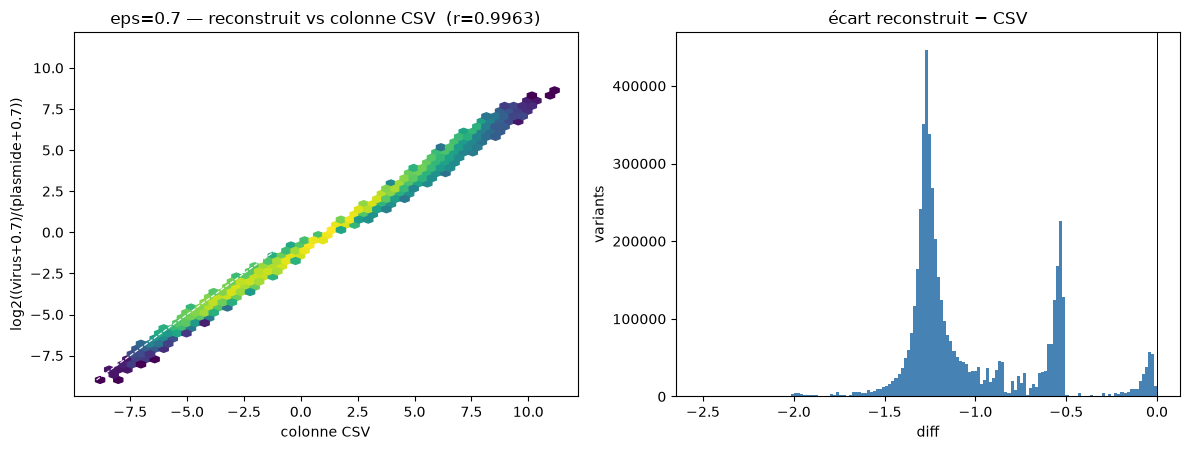

In [21]:
c_plasmide = df["compte_plasmide"].to_numpy(np.float64)
c_virus    = df["compte_virus"].to_numpy(np.float64)
y_csv      = df[viab_col].to_numpy(np.float64)
finite_csv = np.isfinite(y_csv)

def reconstruct(eps):
    return np.log2((c_virus + eps) / (c_plasmide + eps))

EPS = 0.7
y_eps = reconstruct(EPS)
diff  = y_eps[finite_csv] - y_csv[finite_csv]
r_eps = np.corrcoef(y_eps[finite_csv], y_csv[finite_csv])[0, 1]
print(f"eps={EPS} : r(reconstruit, CSV) = {r_eps:.4f}   "
      f"mean diff = {diff.mean():+.3f}   std = {diff.std():.3f}   max|diff| = {np.abs(diff).max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hexbin(y_csv[finite_csv], y_eps[finite_csv], gridsize=50, bins="log", mincnt=1, cmap="viridis")
lo, hi = min(y_csv[finite_csv].min(), y_eps[finite_csv].min()), max(y_csv[finite_csv].max(), y_eps[finite_csv].max())
axes[0].plot([lo, hi], [lo, hi], "w--", lw=0.8)
axes[0].set(title=f"eps={EPS} — reconstruit vs colonne CSV  (r={r_eps:.4f})",
            xlabel="colonne CSV", ylabel=f"log2((virus+{EPS})/(plasmide+{EPS}))")
axes[1].hist(diff, bins=150, color="steelblue")
axes[1].axvline(0, color="k", lw=0.7)
axes[1].set(title="écart reconstruit − CSV", xlabel="diff", ylabel="variants")
plt.tight_layout(); plt.show()

In [22]:
from scipy.optimize import minimize_scalar

EPS_GRID = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
rows = []
for eps in EPS_GRID:
    y_e = reconstruct(eps)[finite_csv]
    d = y_e - y_csv[finite_csv]
    rows.append({
        "eps": eps, "r": np.corrcoef(y_e, y_csv[finite_csv])[0, 1],
        "mean_diff": d.mean(), "std_diff": d.std(), "max_abs_diff": np.abs(d).max(),
        "sse": float(np.sum(d ** 2)),
    })
sweep = pd.DataFrame(rows).set_index("eps").round(4)
display(sweep)

def sse_of_eps(eps):
    if eps <= 0:
        return np.inf
    d = reconstruct(eps)[finite_csv] - y_csv[finite_csv]
    return float(np.sum(d ** 2))

opt = minimize_scalar(sse_of_eps, bounds=(1e-3, 10), method="bounded")
eps_star = opt.x
d_star = reconstruct(eps_star)[finite_csv] - y_csv[finite_csv]
print(f"\neps* (minimise la SSE) = {eps_star:.4f}   "
      f"r={np.corrcoef(reconstruct(eps_star)[finite_csv], y_csv[finite_csv])[0, 1]:.4f}   "
      f"mean diff={d_star.mean():+.3f}   std={d_star.std():.3f}   max|diff|={np.abs(d_star).max():.3f}")
print("-> si mean/std/max restent loin de 0 même à eps*, l'écart n'est pas qu'un pseudocount "
      "différent -- probablement une normalisation (taille de librairie) en plus du log-ratio brut.")

,r,mean_diff,std_diff,max_abs_diff,sse
eps,,,,,
0.1,0.9999,-1.2192,0.0741,1.5236,7.526629e+06
0.3,0.9990,-1.1487,0.1961,1.9380,6.851575e+06
0.5,0.9978,-1.0905,0.2949,2.2594,6.437961e+06
0.7,0.9963,-1.0407,0.3783,2.5218,6.186248e+06
1.0,0.9940,-0.9776,0.4832,2.8428,5.999883e+06
1.5,0.9899,-0.8935,0.6226,3.2563,5.983427e+06
2.0,0.9859,-0.8269,0.7332,3.5768,6.161876e+06
3.0,0.9781,-0.7258,0.9027,4.0592,6.768649e+06



eps* (minimise la SSE) = 1.2654   r=0.9919   mean diff=-0.930   std=0.562   max|diff|=3.077
-> si mean/std/max restent loin de 0 même à eps*, l'écart n'est pas qu'un pseudocount différent -- probablement une normalisation (taille de librairie) en plus du log-ratio brut.
